In [ ]:
# Displays S/N degradation as function of DC 

In [1]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# load stuff
repo_root = Path.cwd().resolve()
sim_pipeline = repo_root / "sim_pipeline"
if not sim_pipeline.is_dir():
    sim_pipeline = repo_root.parent / "sim_pipeline"
if str(sim_pipeline) not in sys.path:
    sys.path.insert(0, str(sim_pipeline))

# If you edited calculator.py in this session, reload so new names are visible
import modules.core.calculator as calculator
importlib.reload(calculator)

# read_s2n_cube_hdf5 (.hdf5 only) or load_s2n_cube (.hdf5 or .pkl)
read_s2n_cube_hdf5 = getattr(calculator, "read_s2n_cube_hdf5", calculator.load_s2n_cube)

In [2]:
# Path to S/N cubes HDF5 written by save_s2n_cube() in calculator.py
#s2n_hdf5_path = '/Users/eckhartspalding/Documents/git.repos/life_detectors/hdf5_testing/temp_s2n_sweep_planet_index_0000000_Nuniverse_1_Nstar_1_dist_10_Rp_1_Rs_1_Ts_5778_L_1.0_z_3_eclip_lon_135_eclip_lat_45_Stype_G/dc_5_qe_0.90_s2n_cube.hdf5'
s2n_hdf5_path = '/Users/eckhartspalding/Downloads/qe_0.60_s2n_cube.hdf5'


cube = read_s2n_cube_hdf5(s2n_hdf5_path)

# Primary array: shape (wavelength, DC, QE)
snr_cube = cube.snr
wavelength = cube.wavelength
dark_current = cube.dark_current
qe = cube.qe

print('-------- VITAL STATISTICS --------')
print("snr_cube shape (wavelength, DC, QE):", snr_cube.shape)
print("wavelength (um):", wavelength.min(), "-", wavelength.max())
print("dark_current (e/pix/s):", dark_current)
print("qe:", qe)
print('----------------------------------')

-------- VITAL STATISTICS --------
snr_cube shape (wavelength, DC, QE): (301, 200, 1)
wavelength (um): 1.004987562112089 - 19.887162466508766
dark_current (e/pix/s): [0.    0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009 0.01  0.011
 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02  0.021 0.022 0.023
 0.024 0.025 0.026 0.027 0.028 0.029 0.03  0.031 0.032 0.033 0.034 0.035
 0.036 0.037 0.038 0.039 0.04  0.041 0.042 0.043 0.044 0.045 0.046 0.047
 0.048 0.049 0.05  0.051 0.052 0.053 0.054 0.055 0.056 0.057 0.058 0.059
 0.06  0.061 0.062 0.063 0.064 0.065 0.066 0.067 0.068 0.069 0.07  0.071
 0.072 0.073 0.074 0.075 0.076 0.077 0.078 0.079 0.08  0.081 0.082 0.083
 0.084 0.085 0.086 0.087 0.088 0.089 0.09  0.091 0.092 0.093 0.094 0.095
 0.096 0.097 0.098 0.099 0.1   0.101 0.102 0.103 0.104 0.105 0.106 0.107
 0.108 0.109 0.11  0.111 0.112 0.113 0.114 0.115 0.116 0.117 0.118 0.119
 0.12  0.121 0.122 0.123 0.124 0.125 0.126 0.127 0.128 0.129 0.13  0.131
 0.132 0.133 0.134 0.135 0.136 

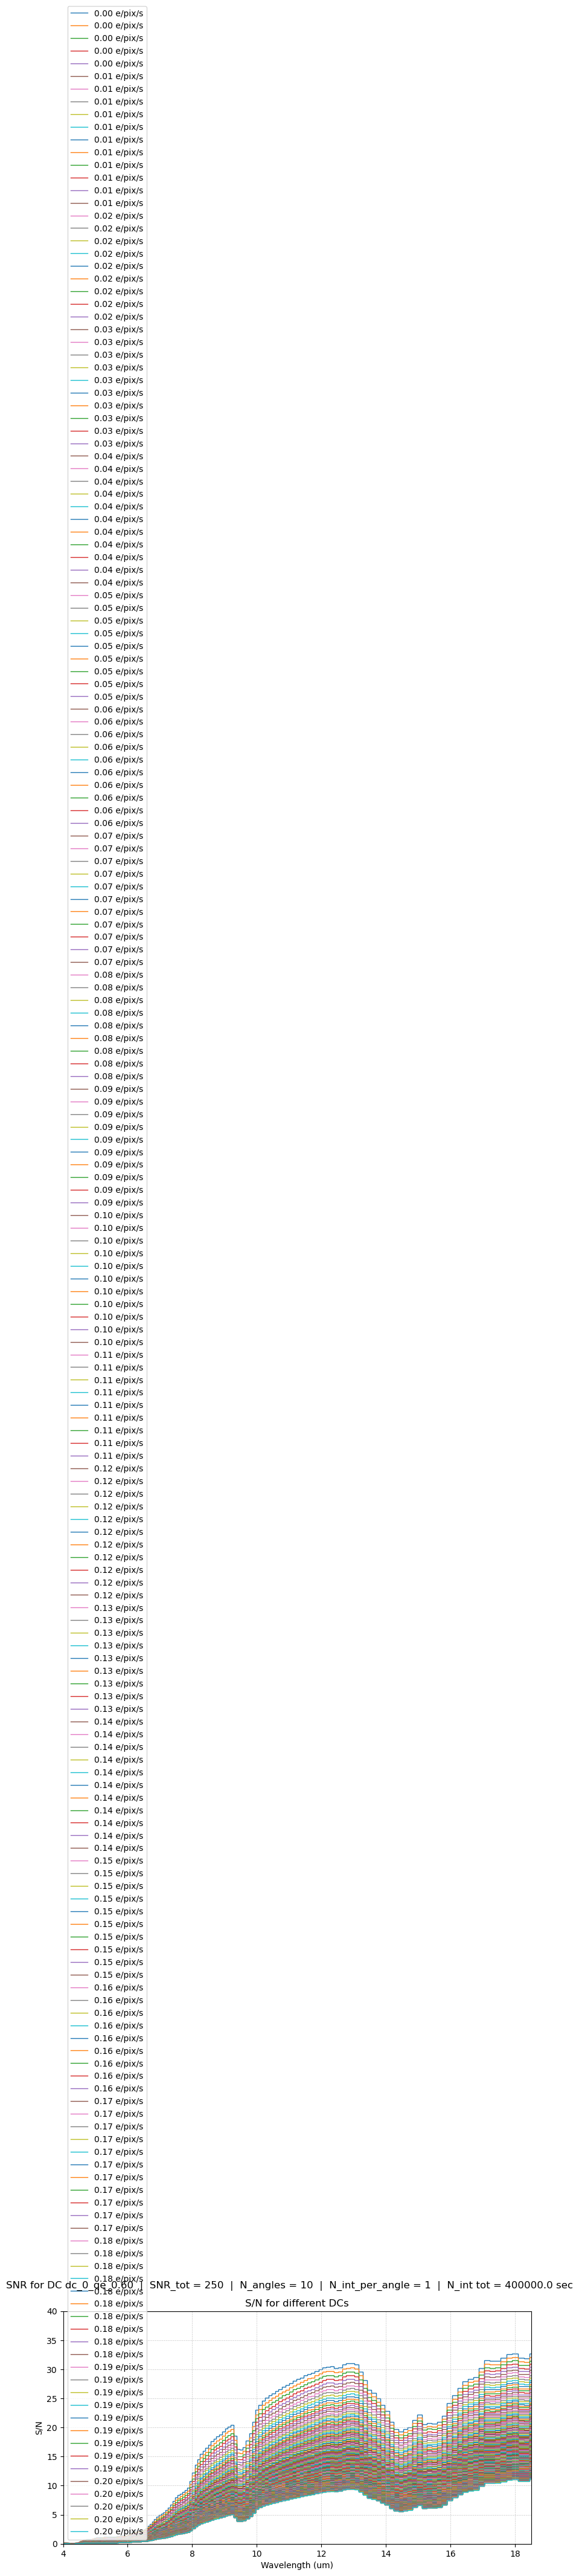

In [10]:
# S/N vs wavelength for one QE, varying DC
qe_idx = 0
plt.figure(figsize=(10, 5))
for i_dc, dc_val in enumerate(dark_current):
    if dc_val <= 0.5:
        label_this = f"{dc_val:.2f} e/pix/s"
    else:
        label_this = None
    plt.stairs(
        snr_cube[:, i_dc, qe_idx],
        edges=cube.wavel_bin_edges,
        label=label_this,
        #color='blue',
        #alpha=np.clip(0.5-dc_val, 0.1, 1),
    )
plt.grid(which="both", linestyle="--", linewidth=0.5, alpha=0.7)

plt.xlim(4, 18.5)
plt.ylim(0, 40)
plt.xlabel("Wavelength (um)")
plt.ylabel("S/N")
plt.suptitle(cube.base_titles[0, qe_idx])
plt.title('S/N for different DCs')
plt.legend()
#plt.show()
plt.savefig('/Users/eckhartspalding/Downloads/junk_s2n_vs_dc.pdf')

/var/folders/wb/zn41c4yx58z1ktmcwgv62zyr0000gn/T/ipykernel_53526/2161023726.py:11: RuntimeWarning: All-NaN slice encountered
  max_dc_1d_at_qe_good_s2n = np.nanmax(


'\nfor i_dc, dc_val in enumerate(dark_current):\n    plt.stairs(\n        snr_cube[:, i_dc, qe_idx],\n        edges=cube.wavel_bin_edges,\n        label=f"DC = {dc_val:g} e/pix/s",\n    )\n'

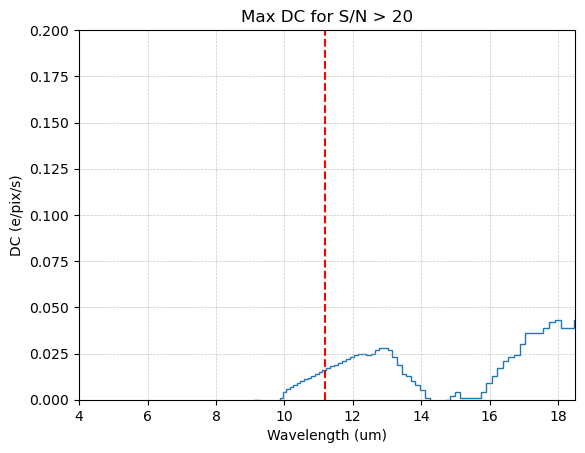

In [ ]:
# plot the maximum DC for a given S/N = N at a given wavelength bin
# (wavelength, DC, QE)

s2n_min = 10.
qe_idx = 0
snr_2d_at_qe = snr_cube[:, :, qe_idx]          # shape (n_wavel, n_dc)
good = snr_2d_at_qe > s2n_min
# broadcast DC across wavelength rows
dc_grid = dark_current[np.newaxis, :]
# at each wavelength: max DC where S/N is good; else nan
max_dc_1d_at_qe_good_s2n = np.nanmax(
    np.where(good, dc_grid, np.nan),
    axis=1,
)


plt.clf()
plt.stairs(
    max_dc_1d_at_qe_good_s2n,
    edges=cube.wavel_bin_edges
    )
plt.grid(which="both", linestyle="--", linewidth=0.5, alpha=0.7)
plt.axvline(x=11.2, color='red', linestyle='--')
plt.xlim(4, 18.5)
plt.ylim(0, 0.2)
plt.xlabel("Wavelength (um)")
plt.ylabel("DC (e/pix/s)")
plt.title("Max DC for S/N > {:.2g} (at QE={:.2g})".format(s2n_min, cube.qe_values[qe_idx]) if hasattr(cube, 'qe_values') else "Max DC for S/N > {:.2g}".format(s2n_min))
#plt.legend()
#plt.show()
plt.savefig('/Users/eckhartspalding/Downloads/junk_max_dc_vs_wavelength.pdf')


#np.where(snr_cube[:, :, qe_idx] > s2n_min)


'''
for i_dc, dc_val in enumerate(dark_current):
    plt.stairs(
        snr_cube[:, i_dc, qe_idx],
        edges=cube.wavel_bin_edges,
        label=f"DC = {dc_val:g} e/pix/s",
    )
'''